<a href="https://colab.research.google.com/github/oczyz-uksw/Projekt-programowanie2/blob/main/projektprogramowanie_danestazystow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

def load_internship_data(internship_path="/content/Internship_Selection_Dataset.csv"):
  return pd.read_csv(internship_path)

internship = load_internship_data()

In [ ]:
internship.head()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,...,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,1,6.87,7,0,0,4,3,2,7,Yes,...,0,7,5,9,3,1,4,4,Yes,1
1,2,9.75,4,4,2,3,3,6,1,Yes,...,3,2,8,8,3,9,8,5,Yes,1
2,3,8.66,2,1,1,2,1,4,6,Yes,...,4,1,5,2,2,1,3,2,Yes,1
3,4,7.99,5,4,2,8,8,10,8,No,...,1,5,5,9,2,7,10,1,Yes,1
4,5,5.78,3,2,2,4,9,1,7,Yes,...,4,7,3,8,7,8,6,5,Yes,1


In [ ]:
internship.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               10000 non-null  int64  
 1   CGPA                     10000 non-null  float64
 2   skills_score             10000 non-null  int64  
 3   projects_count           10000 non-null  int64  
 4   internships_done         10000 non-null  int64  
 5   communication_score      10000 non-null  int64  
 6   aptitude_score           10000 non-null  int64  
 7   coding_test_score        10000 non-null  int64  
 8   resume_score             10000 non-null  int64  
 9   extracurricular          10000 non-null  object 
 10  college_tier             10000 non-null  object 
 11  hackathons_participated  10000 non-null  int64  
 12  certifications_count     10000 non-null  int64  
 13  linkedin_activity_score  10000 non-null  int64  
 14  github_score           

In [ ]:
internship["selected"].value_counts()

,count
selected,
1,7374
0,2626


In [ ]:
internship.describe()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,selected
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.0000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5000.50000,7.470792,5.480200,2.534300,1.502000,5.562800,5.526600,5.44940,5.572200,2.520500,4.474100,5.5000,5.49650,5.480200,5.469400,5.49130,2.502100,0.737400
std,2886.89568,1.438135,2.884829,1.690713,1.115043,2.864765,2.861627,2.86532,2.875868,1.699079,2.871124,2.8876,2.88094,2.881708,2.864557,2.88145,1.711341,0.440069
min,1.00000,5.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.0000,1.00000,1.000000,1.000000,1.00000,0.000000,0.000000
25%,2500.75000,6.230000,3.000000,1.000000,1.000000,3.000000,3.000000,3.00000,3.000000,1.000000,2.000000,3.0000,3.00000,3.000000,3.000000,3.00000,1.000000,0.000000
50%,5000.50000,7.460000,5.000000,3.000000,2.000000,6.000000,6.000000,5.00000,6.000000,3.000000,4.000000,6.0000,6.00000,5.000000,5.000000,5.00000,3.000000,1.000000
75%,7500.25000,8.700000,8.000000,4.000000,2.000000,8.000000,8.000000,8.00000,8.000000,4.000000,7.000000,8.0000,8.00000,8.000000,8.000000,8.00000,4.000000,1.000000
max,10000.00000,10.000000,10.000000,5.000000,3.000000,10.000000,10.000000,10.00000,10.000000,5.000000,9.000000,10.0000,10.00000,10.000000,10.000000,10.00000,5.000000,1.000000


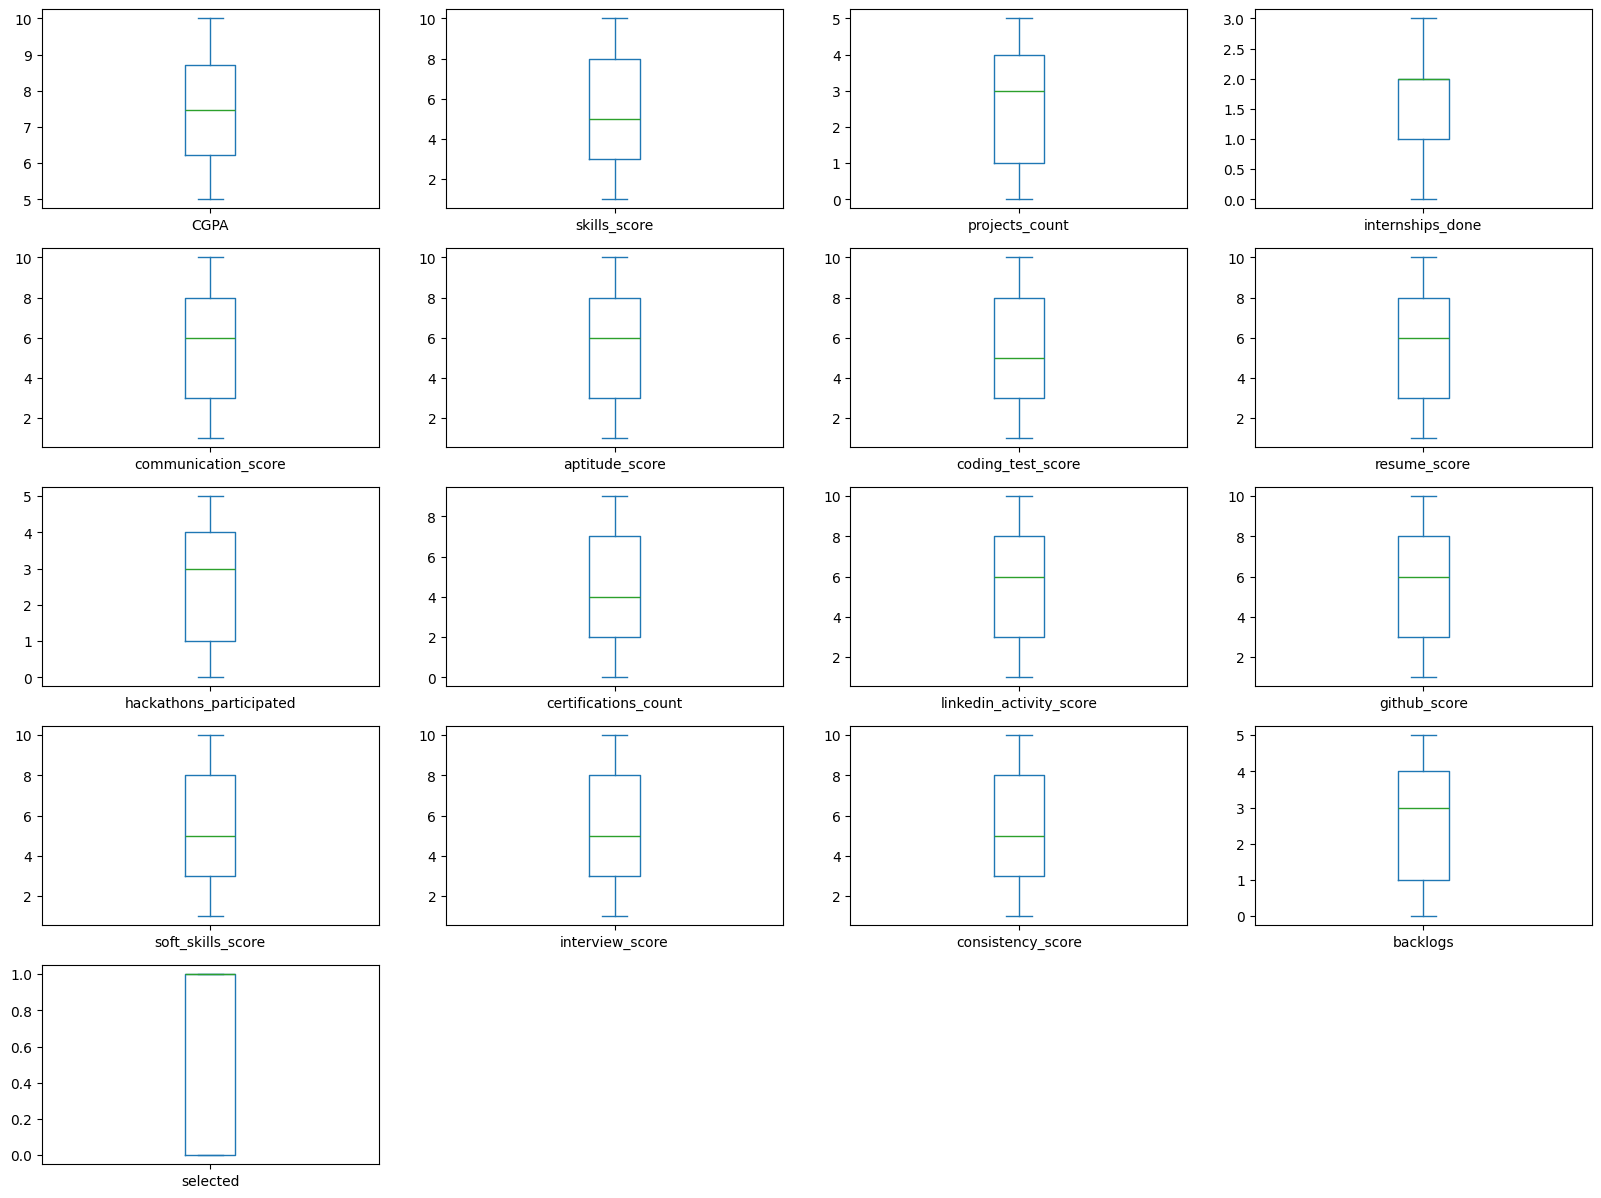

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
internship.select_dtypes(include='number').drop(columns=['student_id']).plot(kind='box', subplots=True, layout=(5,4), figsize=(20,15), sharey=False)
plt.show()

### ***train-test, stratyfikacja***

In [ ]:
from sklearn.model_selection import train_test_split

X = internship.drop(columns=["selected", "student_id"])
y = internship["selected"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
print(f"Rozmiar cech treningowych: {X_train.shape}, testowych: {X_test.shape}")
print(f"Rozmiar targetu treningowego: {y_train.shape}, testowego: {y_test.shape}")

Rozmiar cech treningowych: (8000, 19), testowych: (2000, 19)
Rozmiar targetu treningowego: (8000,), testowego: (2000,)


In [ ]:
print("Proporcje klas w zbiorze treningowym:")
y_train.value_counts(normalize=True)

Proporcje klas w zbiorze treningowym:


,proportion
selected,
1,0.737375
0,0.262625


In [ ]:
print("Proporcje klas w zbiorze testowym:")
y_test.value_counts(normalize=True)

Proporcje klas w zbiorze testowym:


,proportion
selected,
1,0.7375
0,0.2625


In [ ]:
internship = X_train.copy()

### ***wizualizacje i korelacje***

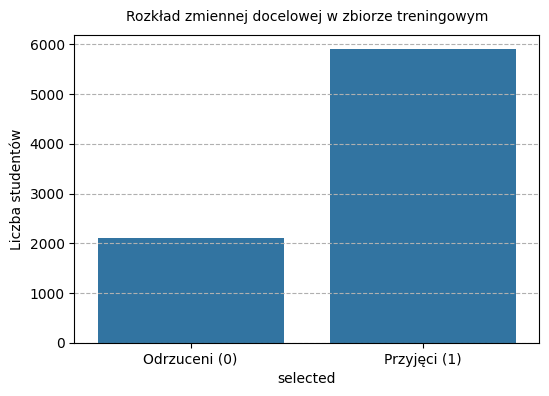

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)

plt.title("Rozkład zmiennej docelowej w zbiorze treningowym", fontsize=10, pad=10)
plt.ylabel("Liczba studentów", fontsize=10)
plt.xticks([0, 1], ["Odrzuceni (0)", "Przyjęci (1)"])
plt.grid(axis='y', linestyle='--')
plt.show()

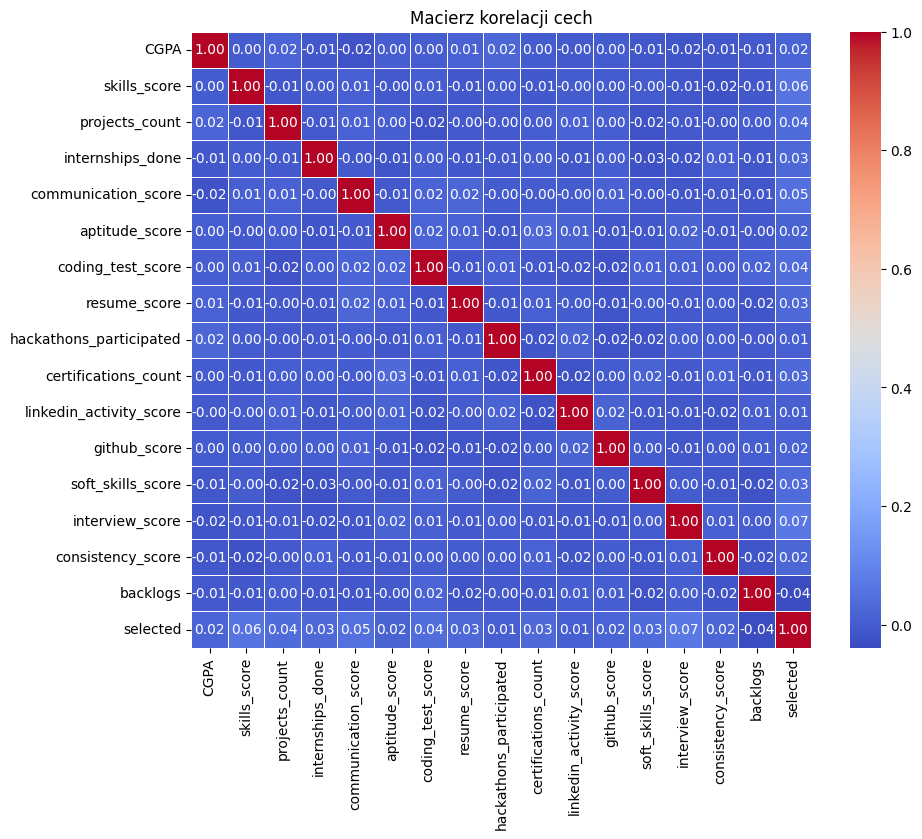

In [ ]:
temp_df = X_train.copy()
temp_df["selected"] = y_train

corr_matrix = temp_df.select_dtypes(include='number').drop(columns=['student_id', 'cgpa_cat'], errors='ignore').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=True)
plt.title("Macierz korelacji cech", fontsize=12)
plt.show()

In [ ]:
print("Macierz pokazuje, że żadna z wejściowych cech nie decyduje ""w pojedynkę"" o przyznaniu stażu -> brak zależności liniowych\n")
print("Korelacja cech ze zmienną 'selected':")
print(corr_matrix["selected"].sort_values(ascending=False))

Macierz pokazuje, że żadna z wejściowych cech nie decyduje w pojedynkę o przyznaniu stażu -> brak zależności liniowych

Korelacja cech ze zmienną 'selected':
selected                   1.000000
interview_score            0.070834
skills_score               0.057356
communication_score        0.049774
coding_test_score          0.038412
projects_count             0.035295
soft_skills_score          0.034889
certifications_count       0.030965
resume_score               0.029941
internships_done           0.029093
consistency_score          0.024896
CGPA                       0.020856
github_score               0.020371
aptitude_score             0.016039
hackathons_participated    0.009878
linkedin_activity_score    0.007776
backlogs                  -0.038699
Name: selected, dtype: float64


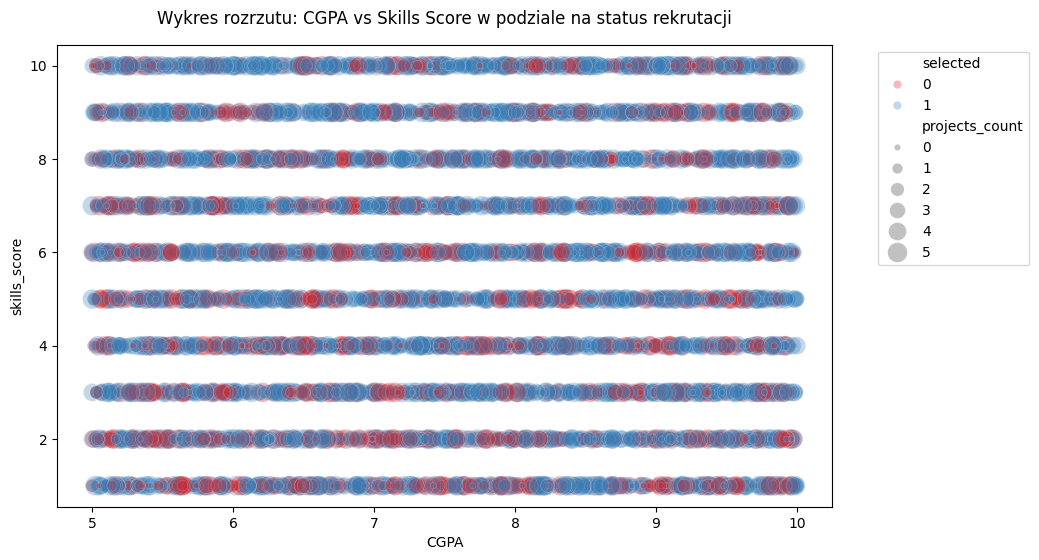

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=temp_df, x="CGPA", y="skills_score", hue="selected", size="projects_count", sizes=(20, 200), alpha=0.3, palette="Set1")

plt.xlabel("CGPA")
plt.ylabel("skills_score")
plt.title("Wykres rozrzutu: CGPA vs Skills Score w podziale na status rekrutacji", fontsize=12, pad=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


### ***czyszczenie danych - pipeline***

In [ ]:
internship.columns

Index(['CGPA', 'skills_score', 'projects_count', 'internships_done',
       'communication_score', 'aptitude_score', 'coding_test_score',
       'resume_score', 'extracurricular', 'college_tier',
       'hackathons_participated', 'certifications_count',
       'linkedin_activity_score', 'github_score', 'soft_skills_score',
       'interview_score', 'consistency_score', 'backlogs',
       'placement_training'],
      dtype='object')

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

cgpa_ix = 0
skills_ix = 1
projects_ix = 2
internships_ix = 3
aptitude_ix = 5
coding_ix = 6
resume_ix = 7
certifications_ix = 9
linkedin_ix = 10
soft_skills_ix = 12
interview_ix = 13

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        total_performance_score = X.iloc[:, interview_ix] + X.iloc[:, coding_ix] + X.iloc[:, skills_ix] + X.iloc[:, soft_skills_ix]
        practical_experience_score = X.iloc[:, projects_ix] + X.iloc[:, internships_ix] + X.iloc[:, resume_ix] + X.iloc[:, linkedin_ix]
        education_score = X.iloc[:, cgpa_ix] + X.iloc[:, certifications_ix] + X.iloc[:, aptitude_ix]

        return np.c_[X, total_performance_score, practical_experience_score, education_score]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


num_attribs = ['CGPA', 'skills_score', 'projects_count', 'internships_done',
    'communication_score', 'aptitude_score', 'coding_test_score',
    'resume_score', 'hackathons_participated', 'certifications_count',
    'linkedin_activity_score', 'github_score', 'soft_skills_score',
    'interview_score', 'consistency_score', 'backlogs',]

cat_attribs = ['extracurricular', 'college_tier', 'placement_training']

num_pipeline = Pipeline([
  ('attribs_adder', CombinedAttributesAdder()),
  ('std_scaler', StandardScaler()),])

cat_pipeline = Pipeline([
  ('one_hot', OneHotEncoder(handle_unknown='ignore')),])

In [ ]:
full_pipeline = ColumnTransformer([
  ("num_pipeline", num_pipeline, num_attribs),
  ("cat_pipeline", cat_pipeline, cat_attribs),
])

internship_prepared = full_pipeline.fit_transform(X_train)
internship_prepared

array([[-0.71982144,  1.56882762, -0.31956101, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.29401157, -0.85674794,  0.2719448 , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.85648057,  0.18278444, -1.50257264, ...,  1.        ,
         0.        ,  1.        ],
       ...,
       [-1.35867511,  1.56882762, -0.91106683, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.9606415 ,  0.87580603, -1.50257264, ...,  0.        ,
         0.        ,  1.        ],
       [-0.01152714,  0.18278444,  0.2719448 , ...,  0.        ,
         0.        ,  1.        ]])

In [ ]:
internship_prepared.shape

(8000, 26)

In [ ]:
pd.DataFrame(internship_prepared)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,-0.719821,1.568828,-0.319561,1.333725,-0.889373,0.162712,0.884766,-1.590888,-1.483953,0.879281,...,1.930286,-1.346355,0.446232,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,0.294012,-0.856748,0.271945,-0.455910,0.158489,1.557882,0.884766,0.846388,-1.483953,-1.564014,...,0.542231,0.194758,0.093647,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.856481,0.182784,-1.502573,-0.455910,1.206351,-1.232459,1.233511,-0.894524,-1.483953,1.577365,...,0.715738,-1.566514,0.508049,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.419005,1.568828,-0.319561,0.438908,-0.190798,-1.581251,-0.858959,0.150023,-0.303402,1.577365,...,0.542231,0.635076,0.134858,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,0.620382,0.875806,0.863451,1.333725,0.857064,-0.534874,-0.161469,-1.242706,0.286874,-0.865930,...,-0.151797,0.414917,-0.714551,1.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0.960641,0.182784,0.271945,-0.455910,-1.587948,0.860297,-1.556448,-0.198159,-1.483953,0.181196,...,-0.325304,-0.025401,1.000294,0.0,1.0,0.0,1.0,0.0,0.0,1.0
7996,-0.157352,0.529295,0.863451,1.333725,-0.190798,0.860297,1.233511,1.194570,0.877150,-1.564014,...,1.236258,1.075394,-0.513074,1.0,0.0,1.0,0.0,0.0,0.0,1.0
7997,-1.358675,1.568828,-0.911067,-1.350727,0.507776,0.860297,1.233511,0.498205,0.286874,1.577365,...,1.930286,-1.126196,1.151402,0.0,1.0,0.0,1.0,0.0,0.0,1.0
7998,0.960641,0.875806,-1.502573,0.438908,-0.889373,-0.534874,-1.207703,1.194570,0.286874,-1.214972,...,-0.672318,-0.685878,-0.831317,1.0,0.0,1.0,0.0,0.0,0.0,1.0


### ***logistic regression***

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(internship_prepared, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

internship_predictions = log_reg.predict(internship_prepared)
accuracy = accuracy_score(y_train, internship_predictions)
print(f"Dokładność modelu na zbiorze treningowym: {accuracy * 100:.2f}%\n")

print("Macierz pomyłek:")
print(confusion_matrix(y_train, internship_predictions))
print("\nOsoby, które nie otrzymały stażu: 1219 - prawidłowo (True Negatives); 882 - błąd (False Positives)\nOsoby, które otrzymały staż: 2513 - błąd (False Negatives); 3386 - prawidłowo (True Positives)")

print("\nRaport klasyfikacji:")
print(classification_report(y_train, internship_predictions))


Dokładność modelu na zbiorze treningowym: 57.56%

Macierz pomyłek:
[[1219  882]
 [2513 3386]]

Osoby, które nie otrzymały stażu: 1219 - prawidłowo (True Negatives); 882 - błąd (False Positives)
Osoby, które otrzymały staż: 2513 - błąd (False Negatives); 3386 - prawidłowo (True Positives)

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.33      0.58      0.42      2101
           1       0.79      0.57      0.67      5899

    accuracy                           0.58      8000
   macro avg       0.56      0.58      0.54      8000
weighted avg       0.67      0.58      0.60      8000



In [ ]:
def display_scores(scores):
    print("Wyniki:", scores)
    print("Średnia:", scores.mean())
    print("Odchylenie standardowe:", scores.std())

In [ ]:
from sklearn.model_selection import cross_val_score

log_reg_scores = cross_val_score(log_reg, internship_prepared, y_train,
                                 scoring="accuracy", cv=10)
display_scores(log_reg_scores)


Wyniki: [0.5225  0.5625  0.59625 0.565   0.55625 0.595   0.54875 0.585   0.58
 0.53875]
Średnia: 0.5650000000000001
Odchylenie standardowe: 0.023116552511133658


### ***decision tree***

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(class_weight='balanced', random_state=42)
tree_clf.fit(internship_prepared, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [ ]:
tree_predictions = tree_clf.predict(internship_prepared)
tree_accuracy = accuracy_score(y_train, tree_predictions)
print(f"Dokładność drzewa na zbiorze treningowym: {tree_accuracy * 100:.2f}%")
if tree_accuracy == 1:
  print("overfitting!\n")

print("Macierz pomyłek:")
print(confusion_matrix(y_train, tree_predictions))

print(classification_report(y_train, tree_predictions))



Dokładność drzewa na zbiorze treningowym: 100.00%
overfitting!

Macierz pomyłek:
[[2101    0]
 [   0 5899]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2101
           1       1.00      1.00      1.00      5899

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



In [ ]:
tree_scores = cross_val_score(tree_clf, internship_prepared, y_train,
                              scoring="accuracy", cv=10)
display_scores(tree_scores)


Wyniki: [0.61375 0.615   0.6475  0.635   0.64    0.605   0.6175  0.60125 0.60375
 0.63625]
Średnia: 0.6214999999999999
Odchylenie standardowe: 0.015917757379731605


### ***random forest***

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
forest_clf.fit(internship_prepared, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
forest_predictions = forest_clf.predict(internship_prepared)
forest_accuracy = accuracy_score(y_train, forest_predictions)
print(f"Dokładność lasu na zbiorze treningowym: {forest_accuracy * 100:.2f}%")
if tree_accuracy == 1:
  print("overfitting!\n")

print("Macierz pomyłek:")
print(confusion_matrix(y_train, forest_predictions))

print(classification_report(y_train, forest_predictions))


Dokładność lasu na zbiorze treningowym: 100.00%
overfitting!

Macierz pomyłek:
[[2101    0]
 [   0 5899]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2101
           1       1.00      1.00      1.00      5899

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



In [ ]:
forest_scores = cross_val_score(forest_clf, internship_prepared, y_train,
                                scoring="accuracy", cv=10)
display_scores(forest_scores)

Wyniki: [0.73625 0.735   0.7375  0.73875 0.73375 0.74    0.73625 0.7375  0.73625
 0.73625]
Średnia: 0.73675
Odchylenie standardowe: 0.001695582495781325


In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

log_reg_cv_predictions = cross_val_predict(log_reg, internship_prepared, y_train, cv=10)

print("Raport klasyfikacji ze sprawdzianu krzyżowego (Regresja Logistyczna):")
print(classification_report(y_train, log_reg_cv_predictions))

tree_cv_predictions = cross_val_predict(tree_clf, internship_prepared, y_train, cv=10)

print("Raport klasyfikacji ze sprawdzianu krzyżowego (Drzewo Decyzyjne):")
print(classification_report(y_train, tree_cv_predictions))

forest_cv_predictions = cross_val_predict(forest_clf, internship_prepared, y_train, cv=10)

print("Raport klasyfikacji ze sprawdzianu krzyżowego, (Las Losowy):\n")
print(classification_report(y_train, forest_cv_predictions))


Raport klasyfikacji ze sprawdzianu krzyżowego (Regresja Logistyczna):
              precision    recall  f1-score   support

           0       0.32      0.56      0.40      2101
           1       0.78      0.57      0.66      5899

    accuracy                           0.56      8000
   macro avg       0.55      0.56      0.53      8000
weighted avg       0.66      0.56      0.59      8000

Raport klasyfikacji ze sprawdzianu krzyżowego (Drzewo Decyzyjne):
              precision    recall  f1-score   support

           0       0.28      0.27      0.27      2101
           1       0.74      0.75      0.74      5899

    accuracy                           0.62      8000
   macro avg       0.51      0.51      0.51      8000
weighted avg       0.62      0.62      0.62      8000

Raport klasyfikacji ze sprawdzianu krzyżowego, (Las Losowy):

              precision    recall  f1-score   support

           0       0.37      0.00      0.01      2101
           1       0.74      1.00      

### ***grid search***

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 4],
    'class_weight': ['balanced', 'balanced_subsample']}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid, cv=5, scoring='f1_macro', n_jobs=-1)

grid_search.fit(internship_prepared, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced', 'balanced_subsample'],
                         'max_depth': [5, 10, None],
                         'max_features': ['sqrt', 4],
                         'n_estimators': [50, 100]},
             scoring='f1_macro')

In [166]:
grid_search.best_params_

{'class_weight': 'balanced_subsample',
 'max_depth': 5,
 'max_features': 'sqrt',
 'n_estimators': 100}

In [167]:
grid_search.best_estimator_

RandomForestClassifier(class_weight='balanced_subsample', max_depth=5,
                       random_state=42)

In [168]:
final_model = grid_search.best_estimator_
final_cv_predictions = cross_val_predict(final_model, internship_prepared, y_train, cv=5)

print("Raport klasyfikacji po Grid Search (Las Losowy):")
print(classification_report(y_train, final_cv_predictions))


Raport klasyfikacji po Grid Search (Las Losowy):
              precision    recall  f1-score   support

           0       0.32      0.50      0.39      2101
           1       0.78      0.62      0.69      5899

    accuracy                           0.59      8000
   macro avg       0.55      0.56      0.54      8000
weighted avg       0.66      0.59      0.61      8000



### ***ocena***

In [169]:
best_model = grid_search.best_estimator_

In [170]:
X_test_prepared = full_pipeline.transform(X_test)

In [171]:
test_pred = best_model.predict(X_test_prepared)

In [172]:
print("OSTATECZNY RAPORT KLASYFIKACJI NA ZBIORZE TESTOWYM:")
print(classification_report(y_test, test_pred))

OSTATECZNY RAPORT KLASYFIKACJI NA ZBIORZE TESTOWYM:
              precision    recall  f1-score   support

           0       0.32      0.53      0.40       525
           1       0.78      0.60      0.68      1475

    accuracy                           0.58      2000
   macro avg       0.55      0.56      0.54      2000
weighted avg       0.66      0.58      0.60      2000

